## Введение 
В этой статье мы поставим перед собой цель создать систему класстеризации информации. За источник информации возьмем мобильные приложения с AppStore, которые нужно разбить на соответсвуцющие им категории (ниши). 



## Реализация 
Реализуем через подход векторизации информации, так как это обеспечит нам удобный семантический подход к сравнению векторов между собой. Поверх будут работать алгоритмы, по типу `HDBSCAN`. Языковая модель будет формировать из них наименованные кластеры. Так же будут учтены и пожелания насчет добавления интерфейса (отоброжения на графике), через сжатие многомерных векторов через `UMAP/t-SNE` и отображение через `Plotly`. 

### numpy 
Идея о хранении векторов в `Pinecone` была отброшена, так как куда уместней и удобней для последующей обработки использовать numpy масивы. 

### OpenAI embeddings 
По модели векторизации выбор пал на продукцию от OpenAI, так как: 

1. Имеет доступный и интегрируемый API, которым я предварительно пользовался, что позволит нам быть уверенными в возможности расширяемости проекта (за счет хорошей интеграции с другими API, например Pinecone)
2. Нет ярко выделеной другой модели, которая была бы чем то сильно лучше чем модель от OpenAI
3. Больше документации о приципе работы, учитывая и официальный сайт
4. Не имеет никаких ограничений в запуске, например в локальной запуске, как это с моделью open-source от BAAI.  

Выбрана модель `text-embedding-3-small` за ее более дешевую стоимость (если сравнивать с `text-embedding-3-large`) и не большое отставание в качестве (детальнее рассмотрено в `OpenAI Embeddings`). 


### OpenAI Model 
Модель нам нужна, чтобы выполнять задачу наименования кластеров: мы передаем модели список названий приложений, а она формирует из них название и описание ниши. 


За модель для наименования кластеров - была выбрана так же OpenAI модель, ведь: 

- Простая интеграция через API без необходимости поднимать локальную модель
- Хорошая синхронизация с ранее упомянутой `text-embedding-3-small` (ведь продукт одной компании)
- Достаточное качество для задачи кластеризации при низкой цене
- `gpt-4o-mini` для именования — дешёвый и достаточно умный для генерации названий ниш




### OpenAI Embeddings Research 
P.S написано на базе OpenAI документации (вся информация оттуда). 

Embeddings - это способ измерить "похожость" текстов. Текст первращается в вектор из чисел типа `float`. Чем меньше расстояние между двумя векторами — тем больше тексты похожи по смыслу.

Для чего это, в основном можно использовать? 

- Кластеризация (можем объеденять векторы в кластеры, при помощи спец алгоритмов и использовать их) 
- Рекомендации (векторизация поискового запроса и рекомендация продукции с близкой схожестью) 
- Поиск (векторизация запроса пользователя и сопосотавления с векторами в БД) 
- Классификация (если вектор - приложение, находим к какому классу оно относится (фитнес, финансы ..) 
- Обнаружение аномалий (имеем возможноть обнаруживать аномальные векторы, которые не соответсвуют кучности векторов) 

#### Таблица моделей OpenAI Embeddings

| Модель | Страниц за $1 | Качество (MTEB) | Макс. токенов |
|---|---|---|---|
| text-embedding-3-small | 62,500 | 62.3% | 8192 |
| text-embedding-3-large | 9,615 | 64.6% | 8192 |
| text-embedding-ada-002 | 12,500 | 61.0% | 8192 |


По таблице видно, что нет ярко выраженного лидера по критерию качества, но есть определенный лидер по стоимости за страницу - `text-embedding-3-small`, поэтому нам выгодного его использовать. 


#### Технические детали 
Важные технические детали:

- `text-embedding-3-small` возвращает вектор из 1536 чисел
- `text-embedding-3-large` — 3072 числа
- Векторы нормализованы до длины 1, поэтому косинусное сходство и евклидово расстояние дают одинаковый результат
- Лимит входного текста — 8192 токена
- Ограничение: модели не знают о событиях после сентября 2021 — но для твоей задачи это вообще не важно.



## Анализ структуры данных 
Для вектора нужна чистая информация, которая желательно не содержит никакой дополнительной (ненужной) информации. Для поиска такой чистой информации была проанализирована структура данных: 


- **Структура данных**: JSON
- **Количество колонок**: 7
- **Из них информативных**: 4
  - `trackName`: имя приложения (нейтрально для вектора, но иногда имя отображает нишу, поэтому может быть и полезно) 
  - `description`: сырой текст с ценами, юридическими текстами, ссылками на privacy policy (шум, портящий вектор)
  - `overview`: чистый AI-сгенерированный summary о том что делает приложение (ценно для вектора)
  - `features`: конкретный список функций, именно по ним приложения отличаются друг от друга (очень ценно для вектора)
- **Выбрано для составления вектора**: 3
  - trackName
  - overview
  - features



## Выбор алгоритма кластеризации 

#### 1. KMeans 
В нашей задаче **KMeans** не был выбран по следующим причинам: 

1. KMeans требудет заранее задать количество кластеров (что мы исходя из задачи сделать не можем)
2. Нужно дополнительно думать и решать проблему "проклятия размерности" (вероятнее всего через **PCA**) что утяжеляет алгоритм и разработку


#### 2. HDBSCAN
Был выбран **HDBSCAN** по следующим причинам: 

1. Не нужно задавать количество кластеров (это нам подходит, т.к мы не знаем количество субниш)
2. Умеет выбрасывать шум (аномалии), то есть приложения которые не относятся ни к какой группе - они получают метку `-1`.
3. Хорошо справляется с задачей нахождения кластеров разной формы, что нам нужно
4. Хорошо масштабируется и довольно быстра, ссылаясь на hdbscan источник (ссылка в источниках) 




## Итоги 

### Что сделано 
- Векторизация через OpenAI Embeddings
- Кластеризация через UMAP + HDBSCAN
- Именование кластеров через GPT
- Сохранение в JSON и CSV
- Интерактивный график через Plotly (приведен ниже) 

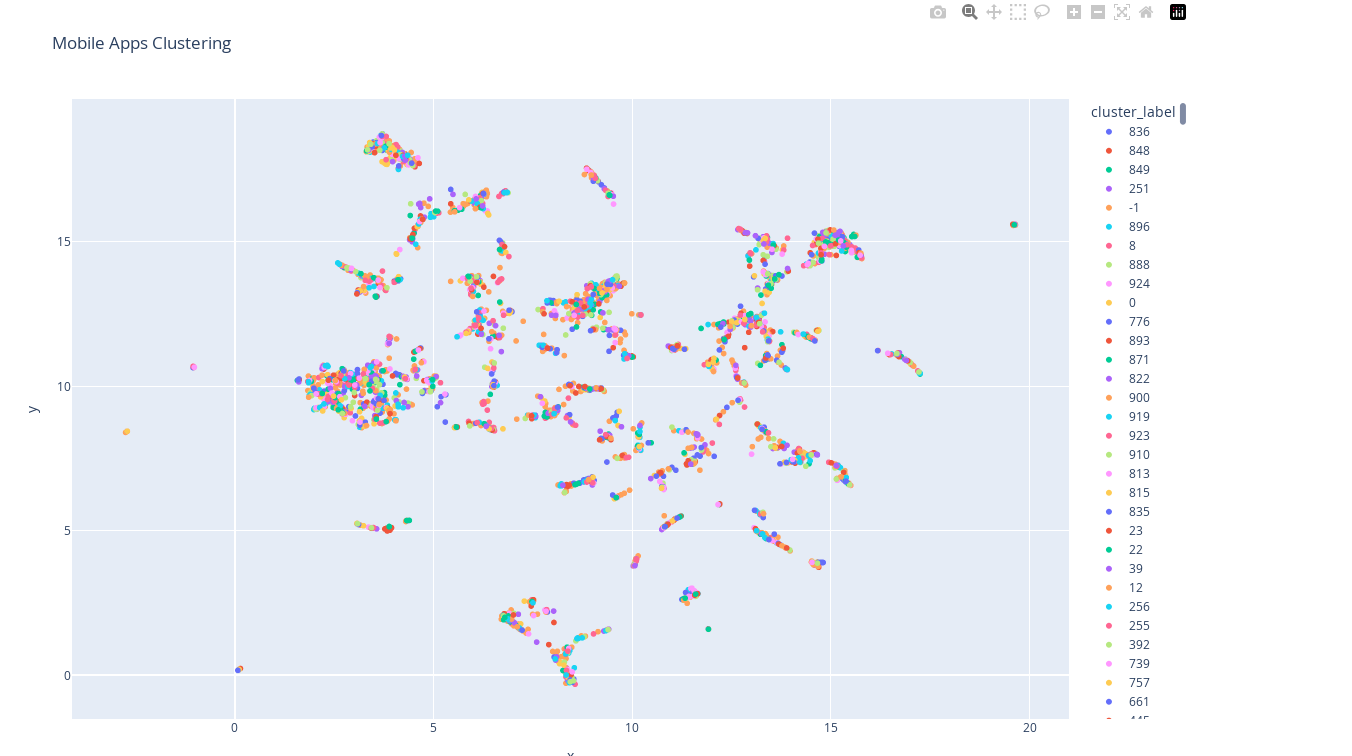


### Эксперименты 
Так же подбирались параметры **UMAP** и **HDBSCAN** чтобы уменьшить шум и получить адекватные кластеры:

Эксперименты:

- `min_cluster_size=3`:  249 кластеров, 852 шума
- `min_cluster_size=2`: 398 кластеров, 801 шума
- `min_cluster_size=2, min_samples=1`: 921 кластер, 968 шума — стало хуже
- `n_components=20`: 409 кластеров, 770 шума
- `n_components=10`: 382 кластера, 665 шума — **лучший результат**
- `n_components=10, n_neighbors=30`: 388 кластеров, 703 шума — хуже

**Вывод**: Лучший баланс достигается при `n_components=10` в UMAP и `min_cluster_size=2, min_samples=1` в HDBSCAN. Снижение размерности до 10 оказало больший эффект на качество чем подбор параметров HDBSCAN. Оставшийся шум (~16%) я посчитал нормальным — не все приложения обязаны попасть в субнишу.


### Добавления в коде 

#### Проблема с отображением через Plotly
`Plotly` требует одинаковую размерность строк в `DataFrame.csv` и `embeddings.npy`, что и логично и привило к ошибке в отображении, т.к по ошибке не были прописаны в сохраняющий методах `index=False`. Ошибка была исправлена. 

`Plotly` визуализация была реализована как отдельный класс, для удобства использования. 

Результаты, как было оговоренно в ТЗ, были сохраненны в `csv` и `json` формат (`results.csv`, `results.json`). 


#### Вынужденное добавление tqdm
При тестировании и разработке очень не удобно не видеть на каком сейчас этапе процесс, особенно, когда он может идти больше 5 минут, как например в случае с `UMAP`, сохранение embeddings в numpy формат, процесс наименование класстеров: для этого, там где это возможно (только в процессе наименование класстеров) была добавлена интеративная визуализация, при помощи бибилиотеки `tqdm`. 


### Выходной результат 
Выходной результат работы кода находится в директории `Output` и состоит из следующего: 

- `DataFrame.csv`: программная csv таблица, которая создаетя при создании embeddings и видоизменяется в течении всего процесса
- `embeddings.npy`: выходной результат работы класса по созданию embeddings - `OpenAiEmbeddings`
- `newplot.png`: изображения из `Plotly`, иллюстрирующее график кластеров (по просьбе в ТЗ) 
- `results.csv`/`results.json`: информативные файлы с полной структурой ниш и списком приложений внутри каждой (по просьбе в ТЗ).  


## Источники 

- **MTEB** (о возможном доминировании определенных Embeddings-моделей над другими) :
  - https://www.emergentmind.com/topics/mteb-english-leaderboard
  - https://modal.com/blog/mteb-leaderboard-article
- **OpenAI Embeddings**
  - Документация (что такое и как работает) : https://developers.openai.com/api/docs/guides/embeddings
- **HDBSCAN**
  - Принцип работы: https://hdbscan.readthedocs.io/en/latest/how_hdbscan_works.html
  - Быстрота и масштабированность, в сравнении с аналогами: https://hdbscan.readthedocs.io/en/latest/performance_and_scalability.html
- **KMeans**
  - Документация: https://scikit-learn.org/stable/modules/generated/sklearn.cluster.KMeans.html
  - "Проклятие размерностей": https://www.emergentmind.com/topics/mteb-and-cmteb-benchmarks




